# **Modelo Matemático da Programação Inteira Mista (PIM) para o Problema ULS**
### **Formulação PIM Padrão**

**Função Objetivo:**
$$
\text{Minimizar } \sum_{t=1}^{n} (p_t x_t + h_t s_t + f_t y_t)
$$

**Sujeito a:**
1. **Balanço de Estoque:** Para $t = 1, \ldots, n$:
   $$
   s_{t-1} + x_t = d_t + s_t \quad \text{com } s_0 = 0
   $$
2. **Restrição de Produção/Setup (Big M):** Para $t = 1, \ldots, n$:
   $$
   x_t \leq M y_t \quad \text{onde M é um limite superior grande para } x_t \text{ (ex: demanda total acumulada)}
   $$
3. **Não-negatividade:** Para $t = 1, \ldots, n$:
   $$
   x_t \geq 0
   $$
   $$
   s_t \geq 0
   $$
4. **Binariedade:** Para $t = 1, \ldots, n$:
   $$
   y_t \in \{0, 1\}
   $$




In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install gurobipy
!pip install numpy

In [4]:
!pip install pandas

In [5]:
!pip install pathlib

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

from pathlib import Path
import os

import pandas as pd

In [8]:
result = Path('result/')
report = Path('report/')
instances = Path('/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls')

In [9]:
import os
# Create a directory in Google Drive to save results
drive_results_path = '/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/results'
if not os.path.exists(drive_results_path):
    os.makedirs(drive_results_path)

In [10]:
MAX_CPU_TIME = 60.0
EPSILON = 1e-6

In [11]:
def readdata(datafile):

    with open(datafile, 'r') as file: linhas = file.readlines()

    # remove linha vazia inicial e elimina os "\n" de cada linha
    linhas = [a.strip() for a in linhas]

    # lendo o tamanho da instancia
    aux = 0
    N = 52

    # definindo vetores
    H = np.zeros(N)
    P = np.zeros(N)
    F = np.zeros(N)
    D = np.zeros(N)

    # lendo e armazenando dados
    aux = aux+1
    F[0] = float(linhas[aux])
    for i in range(1,N):
        F[i] = F[0]

    aux = aux+1
    H[0] = float(linhas[aux])
    for i in range(1,N):
        H[i] = H[0]

    aux = aux+1
    P[0] = float(linhas[aux])
    for i in range(1,N):
        P[i] = P[0]

    aux = aux+1
    D = np.fromstring(linhas[aux], dtype=float, sep = ' ')

    return N, H, P, F, D

In [12]:
def modelo(N, H, P, F, D, model):

    # adicionando variaveis
    x = model.addVars(N, name='x')
    s = model.addVars(N, name='s')
    y = model.addVars(N, vtype=GRB.BINARY, name='y')

    # definindo funcao objetivo
    obj = 0
    for i in range(0, N):
        obj += P[i] * x[i]
        obj += H[i] * s[i]
        obj += F[i] * y[i]

    model.setObjective(obj, GRB.MINIMIZE)

    # definindo restrições
    model.addConstr(x[0] - s[0] == D[0])
    for i in range(1, N):
        model.addConstr(s[i-1] + x[i] - s[i] == D[i])

    for i in range(0, N):
        model.addConstr(x[i] - (D[i:N].sum())*y[i] <= 0)

    model.addConstr(s[N-1] == 0)

    # exportando modelo
    model.write("uls.lp")

    return model

In [13]:
def main(datafile):

    # lendo os dados
    N, H, P, F, D = readdata(datafile)

    # criando o modelo
    model = gp.Model("uls")

    # configurando parametros

    model.setParam("LogFile", "gurobi_log.log")
    model.setParam("LogToConsole", 0)

    model.Params.TimeLimit = MAX_CPU_TIME
    model.Params.MIPGap = EPSILON
    model.Params.method = 0 #-1=automatic, 0=primal, 1=dual , 2=barrier
    model.Params.NodeMethod = 1 #-1=automatic, 0=primal, 1=dual , 2=barrier
    model.Params.Threads = 1
    #model.Params.OutputFlag = 0
    model.Params.Presolve = 0

    # model problem
    modelo(N, H, P, F, D, model)

    # optimize
    model.optimize()

    # get problem status
    tmp = 0
    if model.status == GRB.OPTIMAL:
        tmp = 1

    # imprimindo solucao
    #for var in model.getVars():
    #    print(f"{var.varName} = {var.x}")

    # get results
    objval = model.ObjVal
    objbound = model.ObjBound
    mipgap = model.MIPGap
    runtime = model.Runtime
    nodecount = model.NodeCount

    # imprimindo o valor otimo
    print(f"objval: {round(objval,2)}")
    print(f"objbound: {round(objbound,2)}")
    print(f"runtime: {round(runtime,2)}")
    print(f"mipgap: {round(mipgap,2)}")
    print(f"nodecount: {round(nodecount,2)}")
    print(f"status: {round(tmp,2)}")

    return objval, objbound, mipgap, runtime, nodecount, tmp

In [14]:
if __name__ == "__main__":

    # cria o diretório de resultados se ele não existir
    if not os.path.exists(result):
        os.makedirs(result)

    # limpa o arquivo de resultados antes de escrever
    arquivo = open(os.path.join(result,'uls_std_mip.csv'),'w')
    arquivo.close()


    for dim in [52]:
        for id in range(1,11):
            datafile = f"{instances}/{dim}_{id}.txt"
            print(f"Resolvendo instancia {datafile}")

            objval, objbound, mipgap, runtime, numnode, tmp = main(datafile)

            arquivo = open(os.path.join(result,'uls_std_mip.csv'),'a')
            arquivo.write(datafile+';'
                           +str(round(objval,2))+';'
                           +str(round(objbound,2))+';'
                           +str(round(mipgap,2))+';'
                           +str(round(runtime,2))+';'
                           +str(round(numnode,2))+';'
                           +str(round(tmp,2))+'\n')
            arquivo.close()

Resolvendo instancia /content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_1.txt
Restricted license - for non-production use only - expires 2026-11-23
Set parameter LogFile to value "gurobi_log.log"
Set parameter LogToConsole to value 0
objval: 9269.2
objbound: 9269.2
runtime: 0.22
mipgap: 0.0
nodecount: 279.0
status: 1
Resolvendo instancia /content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_2.txt
Set parameter LogFile to value "gurobi_log.log"
Set parameter LogToConsole to value 0
objval: 9263.4
objbound: 9263.4
runtime: 0.59
mipgap: 0.0
nodecount: 655.0
status: 1
Resolvendo instancia /content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_3.txt
Set parameter LogFile to value "gurobi_log.log"
Set parameter LogToConsole to value 0
objval: 9179.2
objbound: 9179.2
runtime: 0.42
mipgap: 0.0
nodecount: 91.0
status: 1
Resolvendo instancia /content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data

In [23]:
import pandas as pd
import os

data=f'result/uls_std_mip.csv'

df = pd.read_csv(data,header=None,sep=';')

# skip the header row when concatenating
tab = df.iloc[0:].copy()
tab.columns = ['instance','objval','objbound','mipgap','time','nodes','opt']

# convert 'opt' column to float before concatenation
tab['opt'] = tab['opt'].astype(float)

# extract the instance number for sorting and format the instance name
tab['instance'] = tab['instance'].apply(os.path.basename).str.replace('.txt', '', regex=False)


# extract the instance number for sorting
tab['instance_num'] = tab['instance'].str.extract(r'(\d+)_(\d+)').astype(int).sum(axis=1) # Sum parts for sorting


# sort by the extracted instance number
tab = tab.sort_values(by='instance_num').drop(columns='instance_num').reset_index(drop=True)


resume = pd.DataFrame({
    'instance':f"resume",
    'objval':tab["objval"].astype(float).mean(),
    'objbound':tab["objbound"].astype(float).mean(),
    'mipgap':tab['mipgap'].astype(float).mean(),
    'time':tab['time'].astype(float).mean(),
    'nodes':tab['nodes'].astype(float).mean(),
    'opt':tab['opt'].astype(int).sum(),
     },index=[f"uls_mip"]
)

tab = pd.concat([tab, resume], ignore_index=True)

tab["objval"] = tab["objval"].round(2)
tab["objbound"] = tab["objbound"].round(2)
tab["mipgap"] = tab["mipgap"].round(2)
tab["time"] = tab["time"].round(2)
tab["nodes"] = tab["nodes"].round(2)
tab["opt"] = tab["opt"].astype('Int64')
# processar os resultados e criar a tabela resumo

In [16]:
tab

,instance,objval,objbound,mipgap,time,nodes,opt
0,/content/drive/MyDrive/Colab Notebooks_Andress...,9269.20,9269.20,0.0,0.22,279.0,1
1,/content/drive/MyDrive/Colab Notebooks_Andress...,9263.40,9263.40,0.0,0.59,655.0,1
2,/content/drive/MyDrive/Colab Notebooks_Andress...,9179.20,9179.20,0.0,0.42,91.0,1
3,/content/drive/MyDrive/Colab Notebooks_Andress...,9687.00,9687.00,0.0,0.68,221.0,1
4,/content/drive/MyDrive/Colab Notebooks_Andress...,11292.00,11292.00,0.0,0.26,45.0,1
5,/content/drive/MyDrive/Colab Notebooks_Andress...,11347.50,11347.50,0.0,0.50,19.0,1
6,/content/drive/MyDrive/Colab Notebooks_Andress...,11157.00,11157.00,0.0,0.17,1.0,1
7,/content/drive/MyDrive/Colab Notebooks_Andress...,11223.00,11223.00,0.0,0.15,12.0,1
8,/content/drive/MyDrive/Colab Notebooks_Andress...,12575.80,12575.80,0.0,0.17,1.0,1
9,/content/drive/MyDrive/Colab Notebooks_Andress...,12408.00,12408.00,0.0,0.15,1.0,1


## Tables result

In [17]:
# export to .tex format

print(
    tab[['instance','objval','objbound','mipgap','time','nodes','opt']].
    to_latex(index=False,float_format="%.2f")
)

\begin{tabular}{lrrrrrr}
\toprule
instance & objval & objbound & mipgap & time & nodes & opt \\
\midrule
/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_1.txt & 9269.20 & 9269.20 & 0.00 & 0.22 & 279.00 & 1 \\
/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_2.txt & 9263.40 & 9263.40 & 0.00 & 0.59 & 655.00 & 1 \\
/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_3.txt & 9179.20 & 9179.20 & 0.00 & 0.42 & 91.00 & 1 \\
/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_4.txt & 9687.00 & 9687.00 & 0.00 & 0.68 & 221.00 & 1 \\
/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_5.txt & 11292.00 & 11292.00 & 0.00 & 0.26 & 45.00 & 1 \\
/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/data/uls/52_6.txt & 11347.50 & 11347.50 & 0.00 & 0.50 & 19.00 & 1 \\
/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/dat

/tmp/ipython-input-3312261528.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tab_for_plot, x='instance', y='objval', ax=ax1, palette='viridis')


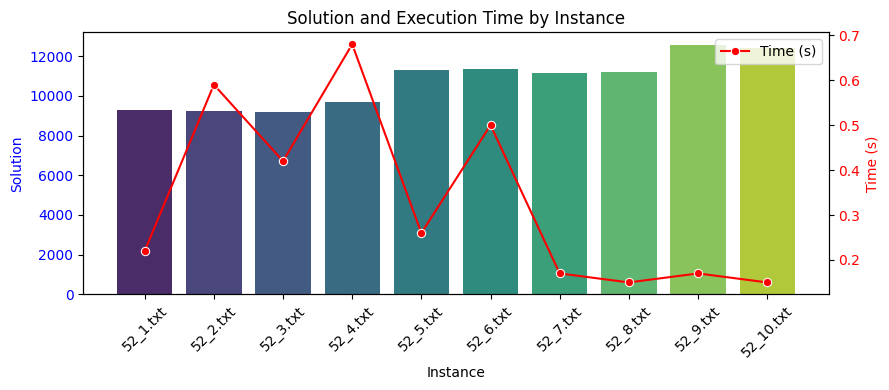

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd


# carrega os dados do arquivo CSV
data=f'result/uls_std_mip.csv'
df = pd.read_csv(data,header=None,sep=';')

# atribui nomes às colunas
df.columns = ['instance','objval','objbound','mipgap','time','nodes','opt']

# garante que a coluna 'instance' seja tratada como string
df['instance'] = df['instance'].astype(str)

# extrai o nome base do arquivo antes de remover duplicados
df['instance'] = df['instance'].apply(os.path.basename)

# remove linhas duplicadas
df = df.drop_duplicates(subset=['instance'], keep='first').reset_index(drop=True)

# converte colunas numéricas para tipos apropriados
df["objval"] = df["objval"].astype(float)
df["objbound"] = df["objbound"].astype(float)
df["mipgap"] = df["mipgap"].astype(float)
df["time"] = df["time"].astype(float)
df["nodes"] = df["nodes"].astype(float)
df["opt"] = df["opt"].astype(int)


# exclui a linha de resumo para plotagem
tab_for_plot = df[df['instance'] != 'resume'].copy()

# cria uma figura e eixos primários
fig, ax1 = plt.subplots(figsize=(9, 4))

# gráfico de barras para o Custo PI no eixo Y primário
sns.barplot(data=tab_for_plot, x='instance', y='objval', ax=ax1, palette='viridis')
ax1.set_xlabel('Instance')
ax1.set_ylabel('Solution', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# rotaciona os rótulos do eixo x para melhor legibilidade
ax1.tick_params(axis='x', rotation=45)


# criar o segundo eixo Y para o Tempo PI
ax2 = ax1.twinx()
sns.lineplot(data=tab_for_plot, x='instance', y='time', ax=ax2, color='red', marker='o', label='Time (s)')
ax2.set_ylabel('Time (s)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# adicionar título e legendas
plt.title('Solution and Execution Time by Instance')

# mostra o gráfico
plt.tight_layout()
plt.show()

In [19]:
# tempo total
total_time = tab_for_plot['time'].sum()

print(f"The sum of the total execution time is: {total_time:.2f}s")

The sum of the total execution time is: 3.31s


In [24]:
import os
import pandas as pd

# assumindo que o dataframe 'tab' está disponível nas células anteriores
# se não, você precisaria carregar os dados novamente

# criar uma nova tabela com colunas selecionadas
selected_columns_tab = tab[['instance', 'objval', 'time']].copy()

# definir o caminho para salvar a nova tabela no google drive
drive_results_path = '/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/results'
selected_columns_table_path = os.path.join(drive_results_path, 'uls_selected_columns_table.csv')

# garantir que o diretório exista antes de salvar
if not os.path.exists(drive_results_path):
    os.makedirs(drive_results_path)

# salvar a nova tabela em um arquivo csv
selected_columns_tab.to_csv(selected_columns_table_path, index=False)

print(f"tabela com colunas selecionadas salva em: {selected_columns_table_path}")
display(selected_columns_tab)
# criar e salvar a tabela com colunas selecionadas no google drive

tabela com colunas selecionadas salva em: /content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/results/uls_selected_columns_table.csv


,instance,objval,time
0,52_1,9269.20,0.22
1,52_2,9263.40,0.59
2,52_3,9179.20,0.42
3,52_4,9687.00,0.68
4,52_5,11292.00,0.26
5,52_6,11347.50,0.50
6,52_7,11157.00,0.17
7,52_8,11223.00,0.15
8,52_9,12575.80,0.17
9,52_10,12408.00,0.15
